# Momentum 12-1

Classic Jegadeesh-Titman 12-1 momentum strategy applied to MOEX stocks. Each month, stocks are ranked by their cumulative return over the past 12 months (excluding the most recent month). The study covers quintile portfolio analysis, long-short backtest, tail quantile optimization, long-only alpha testing vs benchmark, and a practical hedged implementation using IMOEX futures.

In [21]:
# Imports
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from datetime import datetime, timedelta
from scipy import stats
import warnings
warnings.filterwarnings("ignore")

plt.rcParams["figure.figsize"] = (14, 5)
plt.rcParams["axes.grid"] = True
plt.rcParams["grid.alpha"] = 0.3

from data_cache import get_stocks, get_index, RU_UNIVERSE_100, MOEX_INDEX

# Transaction costs (Trader tariff)
COMMISSION_PCT = 0.0005
SLIPPAGE_PCT = 0.0008
TOTAL_COST_PCT = (COMMISSION_PCT + SLIPPAGE_PCT) * 2

# Daily candles for monthly rebalancing
START_DATE = "2022-01-01"  

print("=== Daily candles: 100 stocks ===")
stocks_d = get_stocks(RU_UNIVERSE_100, interval=24, start=START_DATE, verbose=True)


print(f"\nTotal: {len(stocks_d)} daily candles, {stocks_d['ticker'].nunique()} tickers")
print(f"Period: {stocks_d['timestamp'].min().date()} - {stocks_d['timestamp'].max().date()}")

=== Дневные свечи 100 акций ===
  SBER: из кэша (1207 свечей)
  SBERP: из кэша (1207 свечей)
  GAZP: из кэша (1207 свечей)
  LKOH: из кэша (1207 свечей)
  ROSN: из кэша (1207 свечей)
  NVTK: из кэша (1203 свечей)
  GMKN: из кэша (1203 свечей)
  MGNT: из кэша (1207 свечей)
  MOEX: из кэша (1207 свечей)
  VTBR: из кэша (1203 свечей)
  TATN: из кэша (1205 свечей)
  PLZL: из кэша (1200 свечей)
  CHMF: из кэша (1207 свечей)
  NLMK: из кэша (1207 свечей)
  MTSS: из кэша (1206 свечей)
  SNGS: из кэша (1207 свечей)
  AFLT: из кэша (1207 свечей)
  ALRS: из кэша (1207 свечей)
  PHOR: из кэша (1205 свечей)
  RUAL: из кэша (1207 свечей)
  TATNP: из кэша (1205 свечей)
  SNGSP: из кэша (1207 свечей)
  BANE: из кэша (1199 свечей)
  BANEP: из кэша (1199 свечей)
  RNFT: из кэша (1201 свечей)
  TRNFP: из кэша (1203 свечей)
  BSPB: из кэша (1201 свечей)
  CBOM: из кэша (1207 свечей)
  SVCB: из кэша (730 свечей)
  T: из кэша (1177 свечей)
  RENI: из кэша (1201 свечей)
  SFIN: из кэша (1199 свечей)
  SPBE:

In [22]:
# Prepare monthly prices and returns
stocks_d["date"] = stocks_d["timestamp"].dt.date
prices = stocks_d.pivot_table(index="date", columns="ticker", values="close", aggfunc="last")
prices.index = pd.to_datetime(prices.index)

# Monthly prices (last trading day of each month)
monthly_prices = prices.resample("ME").last()

# Monthly returns
monthly_ret = monthly_prices.pct_change()

print(f"Monthly periods: {len(monthly_ret)}")
print(f"Tickers: {monthly_ret.shape[1]}")
print(f"\nData coverage:")
print(f"  Each month has ~{monthly_ret.count(axis=1).mean():.0f} tickers")
print(f"  Tickers with full history: {monthly_ret.dropna(axis=1).shape[1]}")

display(monthly_ret.tail(6).round(3))

Месячных периодов: 54
Тикеров: 109

Покрытие данными (тикеры с не-NaN наблюдениями):
  В каждом месяце доступно ~102 тикеров
  Тикеров с полной историей: 0


ticker,ABRD,AFKS,AFLT,AGRO,AKRN,ALRS,AMEZ,ASTR,BANE,BANEP,...,TRNFP,UPRO,UWGN,VKCO,VRSB,VRSBP,VSMO,VTBR,WUSH,YDEX
date,,,,,,,,,,,,,,,,,,,,,
2026-01-31,-0.010,0.018,-0.010,NaN,0.026,0.005,NaN,0.015,0.088,0.064,...,0.029,0.106,0.045,0.003,0.107,0.141,0.009,0.075,0.011,0.040
2026-02-28,-0.009,0.017,-0.036,NaN,0.026,-0.040,NaN,0.014,-0.035,-0.010,...,0.017,-0.019,-0.047,0.020,-0.041,-0.091,-0.027,0.111,0.123,0.000
2026-03-31,-0.066,-0.115,-0.142,NaN,0.091,-0.141,NaN,-0.044,0.014,0.057,...,-0.056,-0.109,-0.111,-0.106,-0.026,-0.037,-0.066,-0.002,-0.111,-0.108
2026-04-30,-0.040,-0.056,-0.002,NaN,-0.054,-0.178,NaN,0.145,-0.057,0.019,...,0.010,-0.044,-0.083,-0.129,-0.008,0.118,-0.134,0.061,-0.159,-0.042
2026-05-31,-0.060,0.044,0.023,NaN,-0.077,-0.126,NaN,-0.031,-0.045,0.000,...,0.037,-0.065,-0.086,-0.005,-0.055,-0.012,-0.008,-0.135,-0.212,-0.015
2026-06-30,-0.016,0.052,-0.096,NaN,-0.006,-0.028,NaN,-0.305,-0.079,-0.004,...,-0.026,-0.098,-0.080,-0.006,-0.004,0.001,-0.049,-0.052,0.044,-0.003


In [23]:
# 12-1 momentum signal
def compute_momentum_signal(monthly_prices, lookback=12, skip=1):
    """
    Momentum signal: (price_{t-skip} / price_{t-lookback}) - 1"""
    # Price skip months ago / price lookback months ago
    p_recent = monthly_prices.shift(skip)
    p_old    = monthly_prices.shift(lookback)
    return (p_recent / p_old) - 1


# 12-1 momentum: classic
signal_12_1 = compute_momentum_signal(monthly_prices, lookback=12, skip=1)
print(f"Signal 12-1: {signal_12_1.dropna(how='all').shape[0]} periods with signals")

last_signal = signal_12_1.iloc[-1].dropna().sort_values(ascending=False)
print(f"\nLatest date ({signal_12_1.index[-1].date()}):")
print(f"  Top-5 by 12-1 momentum:")
print(last_signal.head().round(3))
print(f"  Bottom-5 by 12-1 momentum:")
print(last_signal.tail().round(3))

Signal 12-1: 42 периодов с сигналами

На последнюю дату (2026-06-30):
  Топ-5 по 12-1 моментуму:
ticker
MRKV     0.876
MRKZ     0.723
MGTSP    0.606
LSNGP    0.603
OKEY     0.574
Name: 2026-06-30 00:00:00, dtype: float64
  Боттом-5 по 12-1 моментуму:
ticker
RASP   -0.489
ETLN   -0.553
WUSH   -0.630
DIAS   -0.637
SMLT   -0.675
Name: 2026-06-30 00:00:00, dtype: float64


In [24]:
# Quintile portfolio construction and backtest
def quintile_portfolios(signal_df, returns_df, n_quintiles=5, min_stocks=20):
    """
    Split stocks into quintiles by signal, compute equal-weight return per quintile."""
    rows = []
    for date in signal_df.index:
        sig_row = signal_df.loc[date].dropna()
        if len(sig_row) < min_stocks:
            continue
        
        # Next month return
        try:
            next_idx = returns_df.index.get_loc(date) + 1
            if next_idx >= len(returns_df):
                continue
            next_date = returns_df.index[next_idx]
        except KeyError:
            continue
        
        next_rets = returns_df.loc[next_date].dropna()
        # Tickers with both signal and return
        common = sig_row.index.intersection(next_rets.index)
        if len(common) < min_stocks:
            continue
        
        sig_common = sig_row[common]
        rets_common = next_rets[common]
        
        # Quintiles
        try:
            q = pd.qcut(sig_common, n_quintiles, labels=False, duplicates="drop")
        except ValueError:
            continue
        
        row = {"date": next_date}
        for i in range(n_quintiles):
            mask = (q == i)
            if mask.sum() > 0:
                row[f"Q{i+1}"] = rets_common[mask].mean()
        rows.append(row)
    
    df = pd.DataFrame(rows).set_index("date")
    df["Q5-Q1"] = df["Q5"] - df["Q1"]
    return df


q_returns = quintile_portfolios(signal_12_1, monthly_ret)

# Summary: mean monthly return per quintile
print(f"Test months: {len(q_returns)}")
print(f"Period: {q_returns.index[0].date()} - {q_returns.index[-1].date()}")
print(f"\nMean monthly return by quintile (%):")
mean_pct = q_returns.mean() * 100
display(mean_pct.round(3))

print(f"\nQ5-Q1 spread statistics:")
print(f"  Q5-Q1 spread: mean = {q_returns['Q5-Q1'].mean()*100:.2f}%/month, "
      f"t-stat = {q_returns['Q5-Q1'].mean() / q_returns['Q5-Q1'].std() * np.sqrt(len(q_returns)):.2f}")
print(f"  Months Q5 > Q1: {(q_returns['Q5-Q1'] > 0).mean()*100:.0f}%")

Тестовых месяцев: 41
Период: 2023-02-28 — 2026-06-30

Средняя месячная доходность по квинтилям (%):


Q1      -0.676
Q2       0.181
Q3       1.633
Q4       1.043
Q5       1.370
Q5-Q1    2.046
dtype: float64


Корреляция Q5 vs Q1 spread (signal & success):
  Q5-Q1 spread: mean = 2.05%/месяц, t-stat = 2.35
  Доля месяцев когда Q5 > Q1: 68%


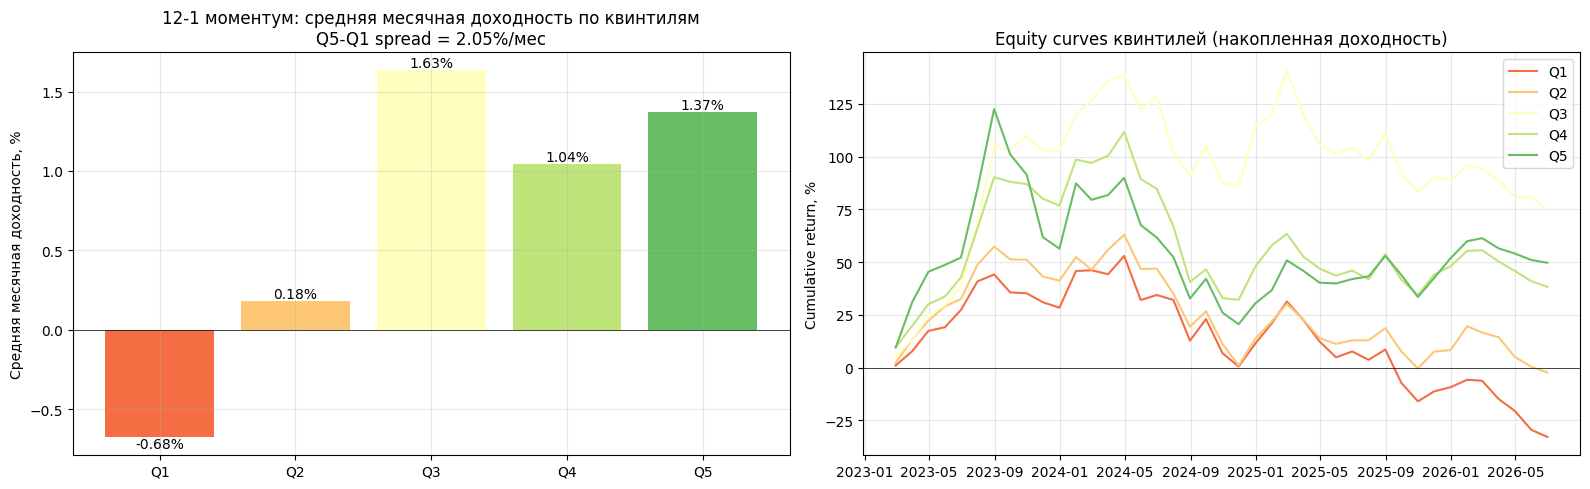

In [25]:
# Quintile return visualization
fig, axes = plt.subplots(1, 2, figsize=(16, 5))

# 1. Mean monthly return by quintile
q_cols = ["Q1", "Q2", "Q3", "Q4", "Q5"]
mean_returns_pct = q_returns[q_cols].mean() * 100

colors = plt.cm.RdYlGn(np.linspace(0.2, 0.8, 5))
bars = axes[0].bar(q_cols, mean_returns_pct, color=colors)
axes[0].axhline(0, color="black", linewidth=0.5)
axes[0].set_title(f"12-1 momentum: mean monthly return by quintile\n"
                   f"Q5-Q1 spread = {(mean_returns_pct['Q5'] - mean_returns_pct['Q1']):.2f}%/mo")
axes[0].set_ylabel("Mean monthly return, %")
for bar, val in zip(bars, mean_returns_pct):
    axes[0].text(bar.get_x() + bar.get_width()/2, val,
                  f"{val:.2f}%", ha="center",
                  va="bottom" if val >= 0 else "top", fontsize=10)

# 2. Equity curves by quintile
for i, q in enumerate(q_cols):
    cum = (1 + q_returns[q]).cumprod() * 100 - 100
    axes[1].plot(cum.index, cum, label=q, color=colors[i], linewidth=1.5)

axes[1].axhline(0, color="black", linewidth=0.5)
axes[1].set_title("Quintile equity curves (cumulative return)")
axes[1].set_ylabel("Cumulative return, %")
axes[1].legend()

plt.tight_layout()
plt.show()

  LONG-SHORT (Q5 long + Q1 short)
  months              : 41.00
  ann_ret_pct         : 23.67
  ann_vol_pct         : 19.33
  sharpe              : 1.22
  max_dd_pct          : 30.34
  win_rate_pct        : 68.29
  avg_monthly_pct     : 1.79

  LONG ONLY (Q5 only)
  months              : 41.00
  ann_ret_pct         : 15.94
  ann_vol_pct         : 31.18
  sharpe              : 0.51
  max_dd_pct          : 46.89
  win_rate_pct        : 51.22
  avg_monthly_pct     : 1.24


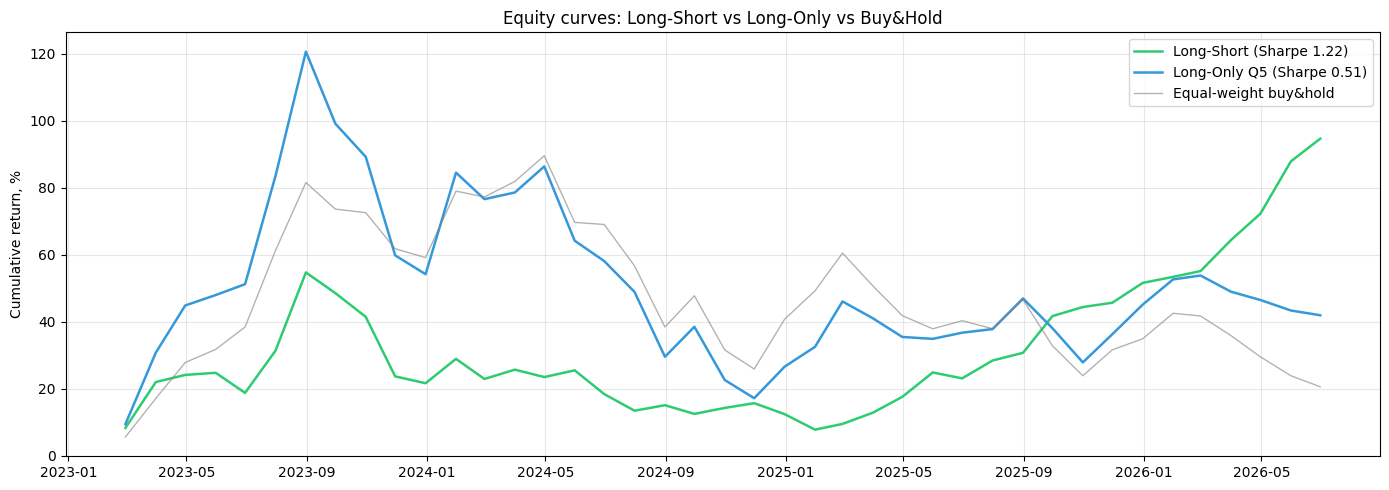

In [26]:
# Long-short and long-only backtest with transaction costs
TURNOVER_COST_MONTHLY = TOTAL_COST_PCT  # ~0.26% monthly rebalancing cost

# Long-short PnL
ls_returns = q_returns["Q5-Q1"] - TURNOVER_COST_MONTHLY
ls_equity = (1 + ls_returns).cumprod() * 100 - 100

# Long-only top quintile
long_only = q_returns["Q5"] - TURNOVER_COST_MONTHLY / 2
long_only_equity = (1 + long_only).cumprod() * 100 - 100


def annualized_metrics(returns):
    """Annualized return, vol, Sharpe from monthly returns."""
    if len(returns) < 2:
        return {}
    ann_ret = (1 + returns.mean()) ** 12 - 1
    ann_vol = returns.std() * np.sqrt(12)
    sharpe = ann_ret / ann_vol if ann_vol > 0 else 0
    cum = (1 + returns).cumprod()
    max_dd = ((cum.cummax() - cum) / cum.cummax()).max()
    return {
        "months": len(returns),
        "ann_ret_pct": ann_ret * 100,
        "ann_vol_pct": ann_vol * 100,
        "sharpe": sharpe,
        "max_dd_pct": max_dd * 100,
        "win_rate_pct": (returns > 0).mean() * 100,
        "avg_monthly_pct": returns.mean() * 100,
    }


m_ls = annualized_metrics(ls_returns)
m_lo = annualized_metrics(long_only)

print(f"{'='*60}")
print(f"  LONG-SHORT (Q5 long + Q1 short)")
print(f"{'='*60}")
for k, v in m_ls.items():
    print(f"  {k:20s}: {v:.2f}")

print(f"\n{'='*60}")
print(f"  LONG ONLY (Q5 only)")
print(f"{'='*60}")
for k, v in m_lo.items():
    print(f"  {k:20s}: {v:.2f}")


# Equity curve
fig, ax = plt.subplots(figsize=(14, 5))
ax.plot(ls_equity.index, ls_equity, color="#2ecc71", linewidth=1.8,
        label=f"Long-Short (Sharpe {m_ls['sharpe']:.2f})")
ax.plot(long_only_equity.index, long_only_equity, color="#3498db", linewidth=1.8,
        label=f"Long-Only Q5 (Sharpe {m_lo['sharpe']:.2f})")

# Compare with equal-weight buy&hold
eq_weight = monthly_ret.mean(axis=1).loc[q_returns.index]
eq_equity = (1 + eq_weight).cumprod() * 100 - 100
ax.plot(eq_equity.index, eq_equity, color="grey", linewidth=1, alpha=0.6,
        label=f"Equal-weight buy&hold")

ax.axhline(0, color="black", linewidth=0.5)
ax.set_title("Equity curves: Long-Short vs Long-Only vs Buy&Hold")
ax.set_ylabel("Cumulative return, %")
ax.legend()
plt.tight_layout()
plt.show()

Сравнение вариантов моментума:


,variant,lookback,skip,months,ls_ann_ret,ls_sharpe,ls_dd,lo_ann_ret,lo_sharpe,Q5-Q1_avg_pct,Q5-Q1_winrate
0,12-1 (classic),12,1,41,23.670,1.224,30.339,15.940,0.511,2.046,68.293
1,6-1,6,1,47,7.256,0.391,20.327,13.336,0.446,0.845,51.064
2,3-1,3,1,50,-9.088,-0.499,37.942,4.058,0.148,-0.531,54.000
3,12-0,12,0,41,33.354,1.449,23.093,23.860,0.728,2.688,70.732
4,6-0,6,0,47,18.424,0.800,16.091,20.162,0.626,1.679,55.319
5,1-0 reversal,1,0,52,19.589,0.790,14.715,18.767,0.594,1.762,57.692


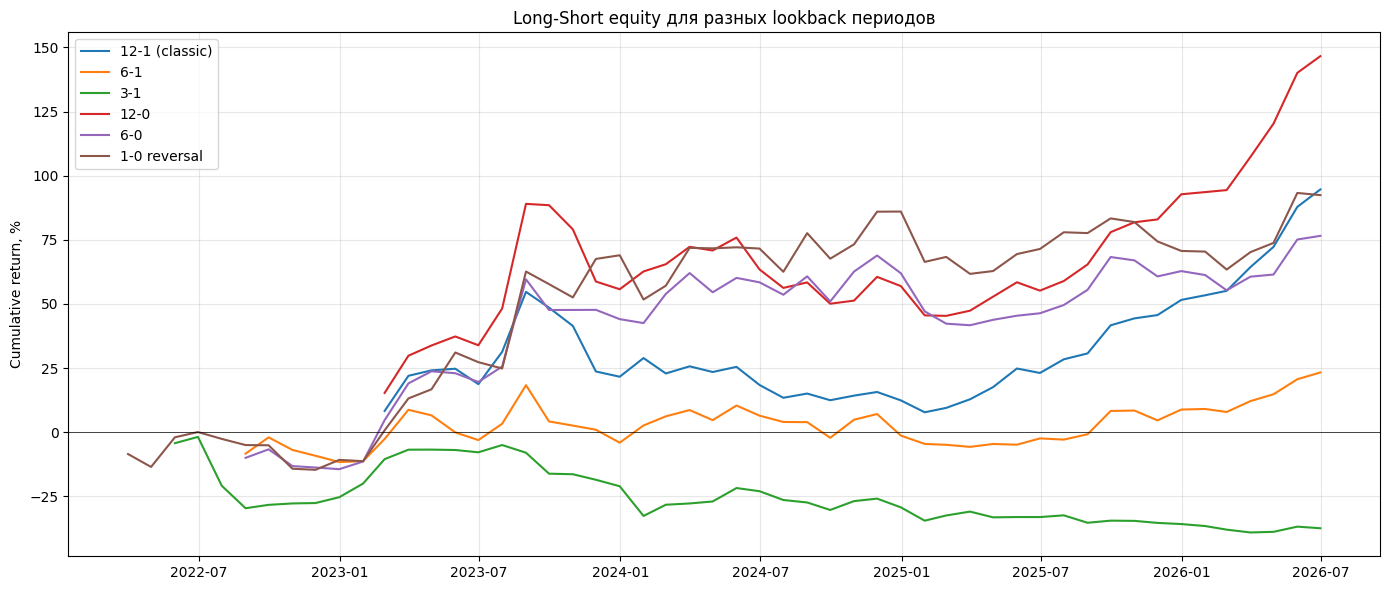

In [27]:
# Lookback period variants
variants = [
    ("12-1 (classic)",  12, 1),
    ("6-1",              6, 1),
    ("3-1",              3, 1),
    ("12-0",            12, 0),
    ("6-0",              6, 0),
    ("1-0 reversal",     1, 0),
]

variant_results = []
variant_curves = {}

for label, lb, sk in variants:
    sig = compute_momentum_signal(monthly_prices, lookback=lb, skip=sk)
    qr = quintile_portfolios(sig, monthly_ret)
    if len(qr) < 6:
        continue
    
    ls_ret = qr["Q5-Q1"] - TURNOVER_COST_MONTHLY
    lo_ret = qr["Q5"] - TURNOVER_COST_MONTHLY / 2
    
    m_ls = annualized_metrics(ls_ret)
    m_lo = annualized_metrics(lo_ret)
    
    variant_results.append({
        "variant": label, "lookback": lb, "skip": sk,
        "months": m_ls["months"],
        "ls_ann_ret": m_ls["ann_ret_pct"],
        "ls_sharpe": m_ls["sharpe"],
        "ls_dd": m_ls["max_dd_pct"],
        "lo_ann_ret": m_lo["ann_ret_pct"],
        "lo_sharpe": m_lo["sharpe"],
        "Q5-Q1_avg_pct": qr["Q5-Q1"].mean() * 100,
        "Q5-Q1_winrate": (qr["Q5-Q1"] > 0).mean() * 100,
    })
    variant_curves[label] = ls_ret

results_variants = pd.DataFrame(variant_results)
print("Momentum variant comparison:")
display(results_variants.round(3))

# Equity curves: all variants
fig, ax = plt.subplots(figsize=(14, 6))
for label, ret in variant_curves.items():
    cum = (1 + ret).cumprod() * 100 - 100
    ax.plot(cum.index, cum, linewidth=1.5, label=label)
ax.axhline(0, color="black", linewidth=0.5)
ax.set_title("Long-Short equity: different lookback periods")
ax.set_ylabel("Cumulative return, %")
ax.legend()
plt.tight_layout()
plt.show()

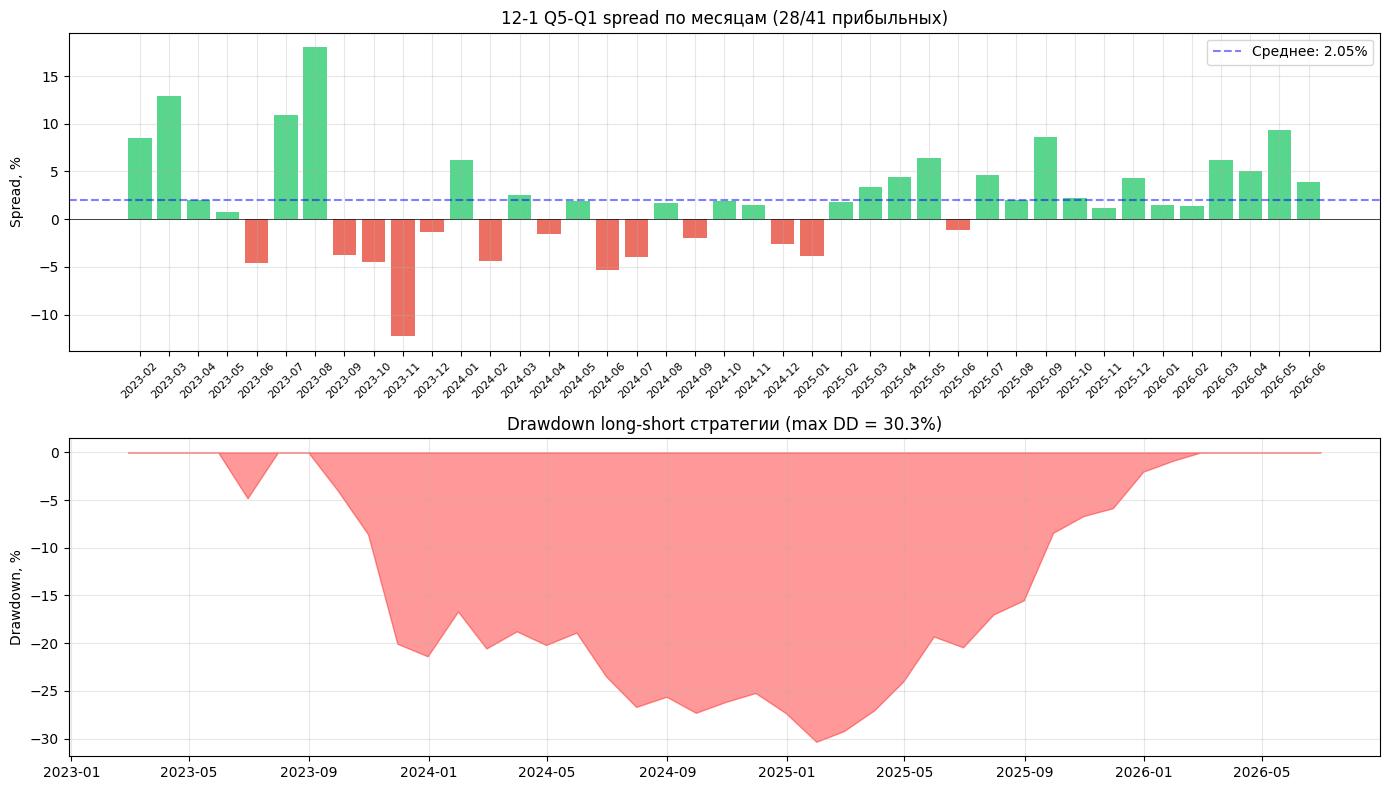

In [28]:
# Month-by-month robustness check
fig, axes = plt.subplots(2, 1, figsize=(14, 8))

# Monthly Q5-Q1 returns
spread = q_returns["Q5-Q1"] * 100
colors_m = ["#2ecc71" if x > 0 else "#e74c3c" for x in spread]
axes[0].bar(range(len(spread)), spread, color=colors_m, alpha=0.8)
axes[0].axhline(0, color="black", linewidth=0.5)
axes[0].axhline(spread.mean(), color="blue", linestyle="--", alpha=0.5,
                label=f"Mean: {spread.mean():.2f}%")
axes[0].set_xticks(range(len(spread)))
axes[0].set_xticklabels([d.strftime("%Y-%m") for d in spread.index],
                         rotation=45, fontsize=8)
axes[0].set_title(f"12-1 Q5-Q1 monthly spread ({(spread>0).sum()}/{len(spread)} profitable)")
axes[0].set_ylabel("Spread, %")
axes[0].legend()

# Drawdown long-short
cum_ls = (1 + ls_returns).cumprod()
dd = (cum_ls.cummax() - cum_ls) / cum_ls.cummax() * 100
axes[1].fill_between(dd.index, -dd, 0, color="red", alpha=0.4)
axes[1].set_title(f"Long-short drawdown (max DD = {dd.max():.1f}%)")
axes[1].set_ylabel("Drawdown, %")

plt.tight_layout()
plt.show()

In [29]:
# Top-N strategy: last month winners/losers
def top_n_strategy(monthly_ret, top_n=5, hold_months=1, side="winners",
                    min_stocks=20, cost_per_rebalance=TOTAL_COST_PCT):
    """
    Top-N strategy: buy best/worst performers from last month, hold for hold_months."""
    rebalance_returns = []
    dates_idx = monthly_ret.index
    
    i = 1  # start from second month (need prior month as signal)
    while i + hold_months <= len(dates_idx):
        # Signal: last month return
        signal_idx = i
        if signal_idx >= len(dates_idx):
            break
        sig = monthly_ret.iloc[signal_idx].dropna()
        if len(sig) < min_stocks:
            i += hold_months
            continue
        
        # Select tickers
        if side == "winners":
            picks = sig.nlargest(top_n).index
        else:
            picks = sig.nsmallest(top_n).index
        
        # Next hold_months months returns, equal-weight
        for h in range(1, hold_months + 1):
            target_idx = signal_idx + h
            if target_idx >= len(dates_idx):
                break
            period_ret = monthly_ret.iloc[target_idx][picks].dropna()
            if period_ret.empty:
                continue
            port_ret = period_ret.mean()
            # Deduct entry cost on first holding month
            if h == 1:
                port_ret -= cost_per_rebalance
            rebalance_returns.append({
                "date": dates_idx[target_idx],
                "ret": port_ret,
                "hold_period": h,
            })
        
        i += hold_months
    
    if not rebalance_returns:
        return pd.Series(dtype=float)
    
    df = pd.DataFrame(rebalance_returns).set_index("date")
    return df["ret"]


configs = []
for top_n in [3, 5, 10, 15]:
    for hold in [1, 2, 3]:
        for side in ["winners", "losers"]:
            ret = top_n_strategy(monthly_ret, top_n=top_n, hold_months=hold, side=side)
            if len(ret) < 6:
                continue
            m = annualized_metrics(ret)
            configs.append({
                "top_n": top_n, "hold": hold, "side": side,
                **m
            })

results_topn = pd.DataFrame(configs).sort_values("sharpe", ascending=False)
print(f"{'='*80}")
print(f"  LAST MONTH WINNERS/LOSERS VARIANTS")
print(f"{'='*80}\n")
display(results_topn.round(3))

best = results_topn.iloc[0]
print(f"\nBest: top-{int(best['top_n'])} {best['side']}, hold {int(best['hold'])} months")
print(f"  Annualized: {best['ann_ret_pct']:.1f}% | Sharpe: {best['sharpe']:.2f} | "
      f"MaxDD: {best['max_dd_pct']:.1f}%")

  ВАРИАНТЫ 'Last Month Winners/Losers'



,top_n,hold,side,months,ann_ret_pct,ann_vol_pct,sharpe,max_dd_pct,win_rate_pct,avg_monthly_pct
18,15,1,winners,52,12.550,32.941,0.381,40.245,51.923,0.990
2,3,2,winners,52,17.280,50.956,0.339,60.769,46.154,1.337
8,5,2,winners,52,11.833,36.516,0.324,56.664,44.231,0.936
6,5,1,winners,52,13.556,42.613,0.318,64.507,51.923,1.065
0,3,1,winners,52,17.573,57.908,0.303,74.370,50.000,1.358
12,10,1,winners,52,8.872,34.298,0.259,46.701,50.000,0.711
23,15,3,losers,51,9.181,36.304,0.253,50.518,47.059,0.735
17,10,3,losers,51,8.707,39.826,0.219,52.092,49.020,0.698
20,15,2,winners,52,5.439,26.236,0.207,45.688,48.077,0.442
5,3,3,losers,51,11.053,54.439,0.203,61.716,49.020,0.877



Лучшая: top-15 winners, hold 1 мес
  Annualized: 12.6% | Sharpe: 0.38 | MaxDD: 40.2%


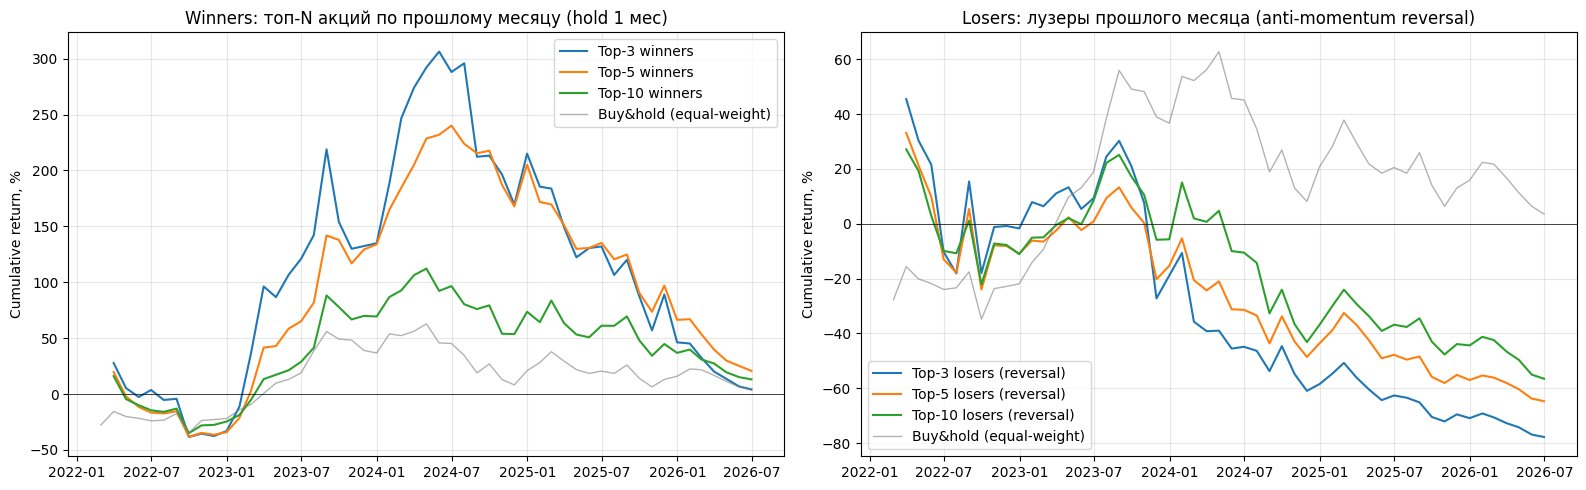


Лучшие конфигурации с holding=1 месяц:


,top_n,side,months,ann_ret_pct,sharpe,max_dd_pct,win_rate_pct
18,15,winners,52,12.550,0.381,40.245,51.923
6,5,winners,52,13.556,0.318,64.507,51.923
0,3,winners,52,17.573,0.303,74.370,50.000
12,10,winners,52,8.872,0.259,46.701,50.000
19,15,losers,52,-6.510,-0.194,60.201,44.231
13,10,losers,52,-11.851,-0.325,65.813,40.385
7,5,losers,52,-14.886,-0.371,73.515,38.462
1,3,losers,52,-19.873,-0.394,84.736,40.385


In [30]:
# Equity curves: winners vs losers
fig, axes = plt.subplots(1, 2, figsize=(16, 5))

# Winners: all variants
for top_n in [3, 5, 10]:
    ret = top_n_strategy(monthly_ret, top_n=top_n, hold_months=1, side="winners")
    if len(ret) > 5:
        cum = (1 + ret).cumprod() * 100 - 100
        axes[0].plot(cum.index, cum, linewidth=1.5, label=f"Top-{top_n} winners")

# Buy&hold benchmark
eq = monthly_ret.mean(axis=1).dropna()
if len(eq) > 5:
    cum_eq = (1 + eq).cumprod() * 100 - 100
    axes[0].plot(cum_eq.index, cum_eq, color="grey", linewidth=1, alpha=0.6,
                  label="Buy&hold (equal-weight)")

axes[0].axhline(0, color="black", linewidth=0.5)
axes[0].set_title("Winners: top-N stocks by last month (hold 1 month)")
axes[0].set_ylabel("Cumulative return, %")
axes[0].legend()

# Losers: short-term reversal
for top_n in [3, 5, 10]:
    ret = top_n_strategy(monthly_ret, top_n=top_n, hold_months=1, side="losers")
    if len(ret) > 5:
        cum = (1 + ret).cumprod() * 100 - 100
        axes[1].plot(cum.index, cum, linewidth=1.5, label=f"Top-{top_n} losers (reversal)")

if len(eq) > 5:
    axes[1].plot(cum_eq.index, cum_eq, color="grey", linewidth=1, alpha=0.6,
                  label="Buy&hold (equal-weight)")

axes[1].axhline(0, color="black", linewidth=0.5)
axes[1].set_title("Losers: last month losers (anti-momentum reversal)")
axes[1].set_ylabel("Cumulative return, %")
axes[1].legend()

plt.tight_layout()
plt.show()

# Comparison table: hold=1 only
print("\nBest configs with holding=1 month:")
display(results_topn[results_topn["hold"] == 1][
    ["top_n", "side", "months", "ann_ret_pct", "sharpe", "max_dd_pct", "win_rate_pct"]
].round(3))

In [31]:
# Tail portfolio returns (top/bottom deciles and quintiles)
def tail_portfolio_returns(signal_df, returns_df, quantile_pct=0.10,
                            hold_months=1, min_stocks=15,
                            cost_per_rebalance=TOTAL_COST_PCT):
    """
    Long top-q% + Short bottom-q% with hold_months holding period."""
    all_dates = returns_df.index
    monthly_pnl = {}

    i = 1
    while i < len(all_dates):
        sig = signal_df.iloc[i - 1].dropna()
        if len(sig) < min_stocks:
            i += hold_months
            continue

        # Select tail quantiles
        n_pick = max(1, int(np.floor(len(sig) * quantile_pct)))
        longs  = sig.nlargest(n_pick).index
        shorts = sig.nsmallest(n_pick).index

        # Hold for hold_months
        for h in range(hold_months):
            target_i = i + h
            if target_i >= len(all_dates):
                break
            date = all_dates[target_i]
            r = returns_df.iloc[target_i]
            long_ret  = r[longs].dropna().mean()
            short_ret = r[shorts].dropna().mean()
            ls_ret    = long_ret - short_ret

            # Deduct costs at rebalance only
            if h == 0:
                ls_ret -= 2 * cost_per_rebalance  # long + short side

            monthly_pnl[date] = ls_ret

        i += hold_months

    return pd.Series(monthly_pnl).sort_index()


def ls_metrics(returns_series):
    """Sharpe, t-stat and basic metrics for monthly L/S returns."""
    r = returns_series.dropna()
    if len(r) < 6:
        return None
    n = len(r)
    mean = r.mean()
    std  = r.std(ddof=1)
    t_stat = mean / (std / np.sqrt(n))
    p_value = 2 * (1 - stats.t.cdf(abs(t_stat), df=n - 1))
    ann_ret = (1 + mean) ** 12 - 1
    ann_vol = std * np.sqrt(12)
    sharpe  = ann_ret / ann_vol if ann_vol > 0 else 0
    cum = (1 + r).cumprod()
    max_dd = ((cum.cummax() - cum) / cum.cummax()).max()
    return {
        "n_months": n,
        "mean_monthly_pct": mean * 100,
        "t_stat": t_stat,
        "p_value": p_value,
        "ann_ret_pct": ann_ret * 100,
        "ann_vol_pct": ann_vol * 100,
        "sharpe": sharpe,
        "max_dd_pct": max_dd * 100,
        "win_rate_pct": (r > 0).mean() * 100,
    }


print("Running parameter grid search...")
print(f"Universe: ~{monthly_ret.count(axis=1).mean():.0f} stocks/month")
print(f"Data: {len(monthly_ret)} months ({monthly_ret.index[0].date()} - {monthly_ret.index[-1].date()})")

Функции готовы. Запускаем перебор параметров...
Универс: ~102 акций/месяц
Данных: 54 месяцев (2022-01-31 — 2026-06-30)


In [32]:
# Grid search: lookback x holding period x quantile
LOOKBACKS  = [1, 2, 3, 6, 12]
HOLDS      = [1, 2, 3, 6, 12]
QUANTILES  = [0.10, 0.20]   # 10% (decile) and 20% (quintile)

all_rows = []
for lb in LOOKBACKS:
    sig = compute_momentum_signal(monthly_prices, lookback=lb, skip=1 if lb >= 2 else 0)
    for hold in HOLDS:
        for q in QUANTILES:
            ret = tail_portfolio_returns(sig, monthly_ret,
                                         quantile_pct=q, hold_months=hold)
            m = ls_metrics(ret)
            if m:
                m.update({"lookback": lb, "hold": hold, "quantile_pct": q})
                all_rows.append(m)

grid_df = pd.DataFrame(all_rows)

print("Full results table (sorted by Sharpe desc):")
display_cols = ["lookback", "hold", "quantile_pct", "n_months",
                "mean_monthly_pct", "t_stat", "p_value",
                "ann_ret_pct", "sharpe", "max_dd_pct", "win_rate_pct"]
display(grid_df[display_cols].sort_values("sharpe", ascending=False).round(3))

sig_mask = grid_df["p_value"] < 0.05
print(f"\nStatistically significant configs (p<0.05): {sig_mask.sum()} of {len(grid_df)}")
if sig_mask.any():
    print("Significant:")
    display(grid_df[sig_mask][display_cols].sort_values("sharpe", ascending=False).round(3))

Полная таблица результатов (sorted by Sharpe desc):


,lookback,hold,quantile_pct,n_months,mean_monthly_pct,t_stat,p_value,ann_ret_pct,sharpe,max_dd_pct,win_rate_pct
45,12,3,0.2,41,2.249,2.541,0.015,30.592,1.558,20.974,70.732
44,12,3,0.1,41,2.809,2.210,0.033,39.438,1.399,31.721,60.976
40,12,1,0.1,41,2.553,2.142,0.038,35.319,1.336,33.728,60.976
41,12,1,0.2,41,1.818,2.063,0.046,24.138,1.235,31.357,68.293
42,12,2,0.1,41,2.596,1.945,0.059,36.000,1.216,31.546,56.098
43,12,2,0.2,41,1.845,1.997,0.053,24.531,1.197,24.380,65.854
47,12,6,0.2,41,1.568,1.981,0.055,20.527,1.169,16.088,65.854
46,12,6,0.1,41,2.282,1.900,0.065,31.090,1.167,27.958,53.659
29,3,12,0.2,41,1.428,1.794,0.080,18.545,1.051,12.727,65.854
37,6,6,0.2,47,1.417,1.800,0.078,18.390,0.984,13.624,59.574



Статистически значимых конфигов (p<0.05): 5 из 50
Значимые:


,lookback,hold,quantile_pct,n_months,mean_monthly_pct,t_stat,p_value,ann_ret_pct,sharpe,max_dd_pct,win_rate_pct
45,12,3,0.2,41,2.249,2.541,0.015,30.592,1.558,20.974,70.732
44,12,3,0.1,41,2.809,2.210,0.033,39.438,1.399,31.721,60.976
40,12,1,0.1,41,2.553,2.142,0.038,35.319,1.336,33.728,60.976
41,12,1,0.2,41,1.818,2.063,0.046,24.138,1.235,31.357,68.293
10,2,1,0.1,51,-2.257,-2.138,0.037,-23.961,-0.917,76.536,33.333


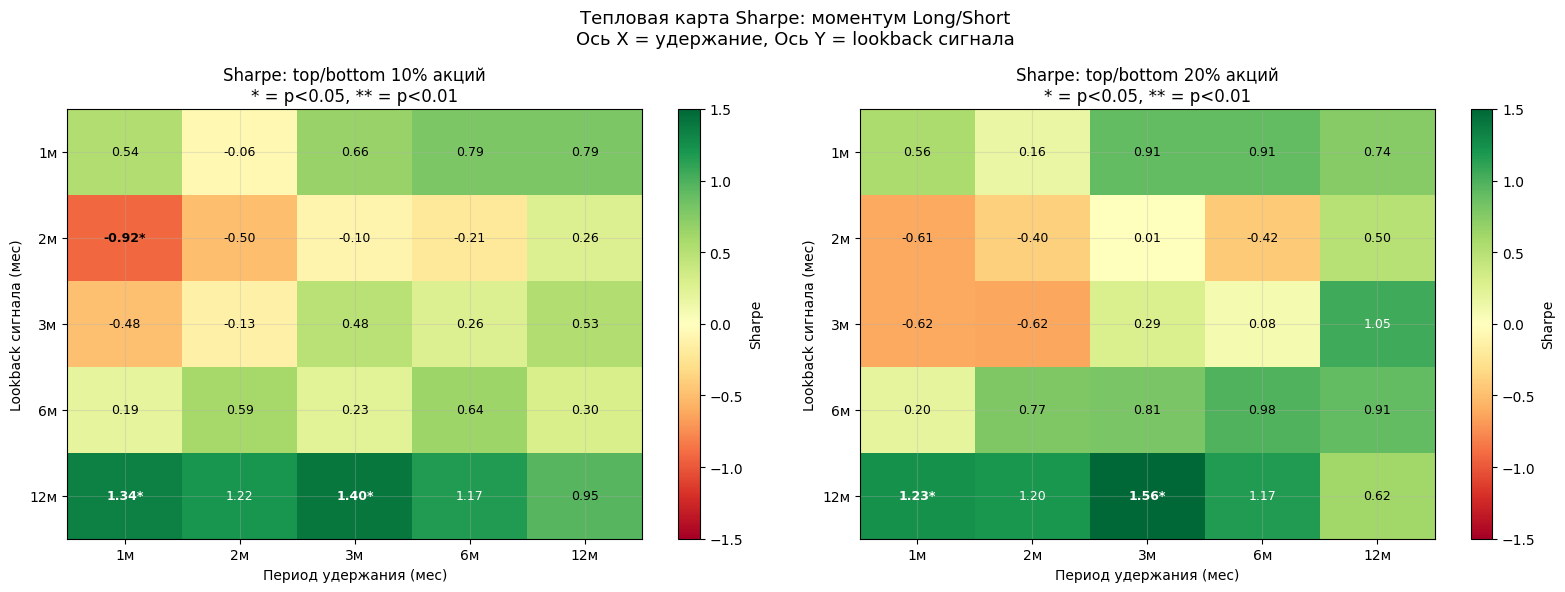


Тепловая таблица t-статистик (top/bottom 10%):


hold↓,1,2,3,6,12
lookback→,,,,,
1,1.04,-0.13,1.24,1.41,1.33
2,-2.14,-1.10,-0.20,-0.43,0.47
3,-1.05,-0.27,0.94,0.50,0.93
6,0.37,1.09,0.44,1.19,0.53
12,2.14,1.95,2.21,1.90,1.59



Тепловая таблица t-статистик (top/bottom 20%):


hold,1,2,3,6,12
lookback,,,,,
1,1.10,0.32,1.68,1.65,1.28
2,-1.33,-0.85,0.01,-0.86,0.90
3,-1.33,-1.33,0.58,0.15,1.79
6,0.39,1.44,1.49,1.80,1.58
12,2.06,2.00,2.54,1.98,1.09


In [33]:
# Sharpe heatmap: lookback x holding period
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

for ax, q in zip(axes, QUANTILES):
    sub = grid_df[grid_df["quantile_pct"] == q]
    pivot_sharpe = sub.pivot(index="lookback", columns="hold", values="sharpe")
    pivot_pval   = sub.pivot(index="lookback", columns="hold", values="p_value")

    im = ax.imshow(pivot_sharpe.values, cmap="RdYlGn", aspect="auto",
                   vmin=-1.5, vmax=1.5)
    plt.colorbar(im, ax=ax, label="Sharpe")

    ax.set_xticks(range(len(HOLDS)))
    ax.set_yticks(range(len(LOOKBACKS)))
    ax.set_xticklabels([f"{h}m" for h in HOLDS])
    ax.set_yticklabels([f"{lb}m" for lb in LOOKBACKS])
    ax.set_xlabel("Holding period (months)")
    ax.set_ylabel("Signal lookback (months)")
    ax.set_title(f"Sharpe: top/bottom {int(q*100)}% stocks\n"
                 f"* = p<0.05, ** = p<0.01")

    # Annotations: Sharpe + significance stars
    for i, lb in enumerate(LOOKBACKS):
        for j, hold in enumerate(HOLDS):
            try:
                sharpe_val = pivot_sharpe.loc[lb, hold]
                p_val = pivot_pval.loc[lb, hold]
            except KeyError:
                continue
            if pd.isna(sharpe_val):
                continue
            star = ""
            if p_val < 0.01:
                star = "**"
            elif p_val < 0.05:
                star = "*"
            ax.text(j, i, f"{sharpe_val:.2f}{star}",
                    ha="center", va="center", fontsize=9,
                    color="black" if abs(sharpe_val) < 1 else "white",
                    fontweight="bold" if star else "normal")

plt.suptitle("Sharpe heatmap: momentum Long/Short\n"
             "X = holding period, Y = signal lookback",
             fontsize=13)
plt.tight_layout()
plt.show()


print("\nt-statistic table (top/bottom 10%):")
sub10 = grid_df[grid_df["quantile_pct"] == 0.10]
pivot_t = sub10.pivot(index="lookback", columns="hold", values="t_stat").round(2)
pivot_t.index.name = "lookback"
pivot_t.columns.name = "hold↓"
display(pivot_t)

print("\nt-statistic table (top/bottom 20%):")
sub20 = grid_df[grid_df["quantile_pct"] == 0.20]
pivot_t20 = sub20.pivot(index="lookback", columns="hold", values="t_stat").round(2)
display(pivot_t20)

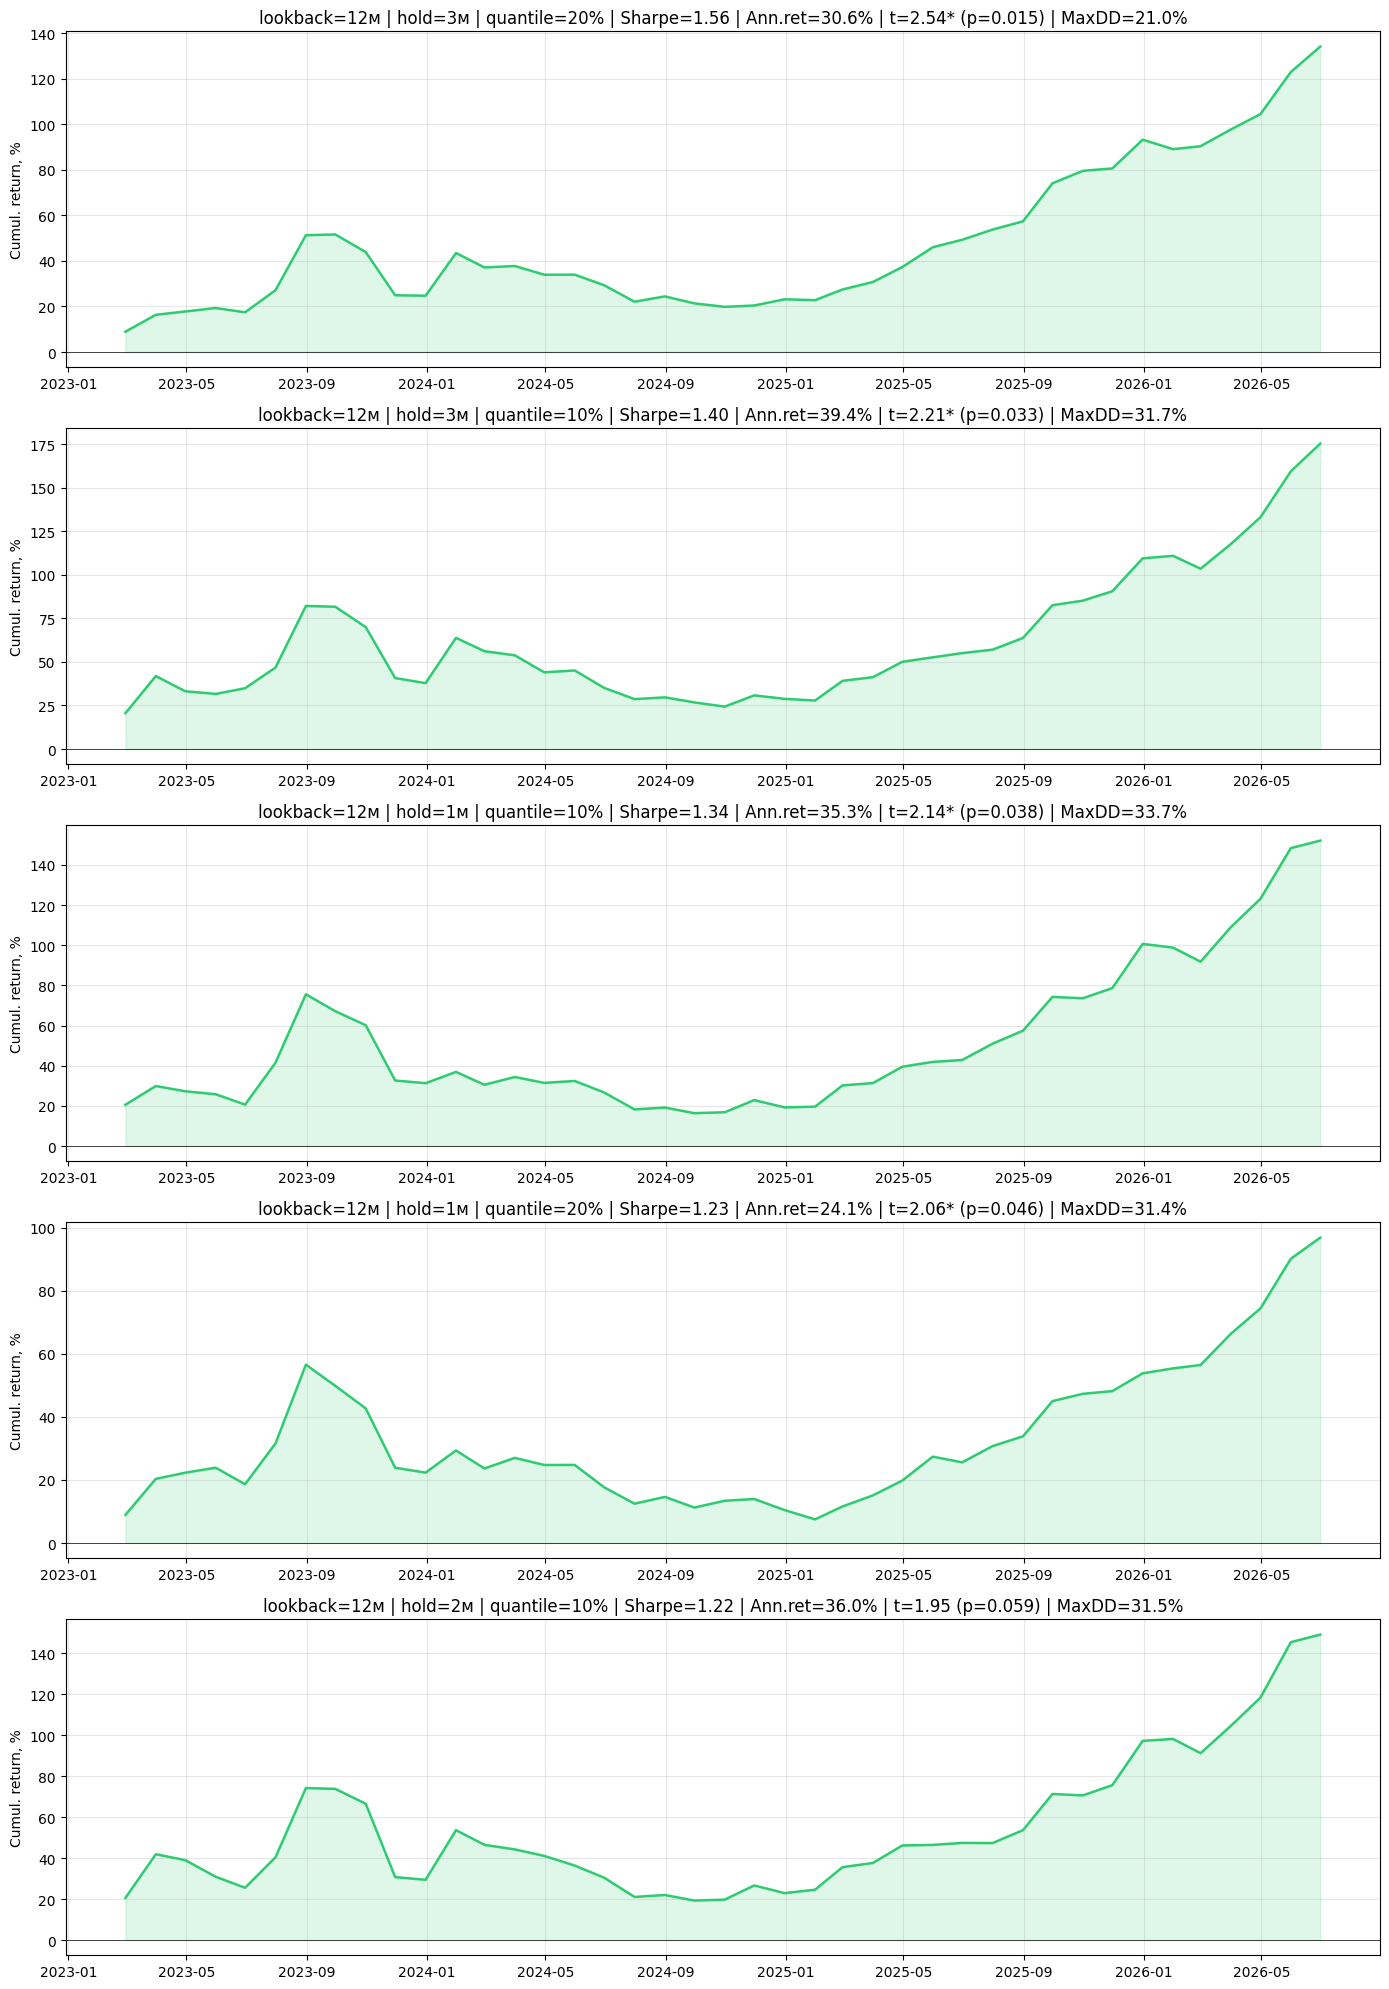

In [34]:
# Top-5 configurations equity curves
top5 = grid_df.sort_values("sharpe", ascending=False).head(5)

fig, axes = plt.subplots(len(top5), 1, figsize=(14, 4 * len(top5)))
if len(top5) == 1:
    axes = [axes]

for ax, (_, row) in zip(axes, top5.iterrows()):
    lb   = int(row["lookback"])
    hold = int(row["hold"])
    q    = row["quantile_pct"]

    sig = compute_momentum_signal(monthly_prices, lookback=lb, skip=1 if lb >= 2 else 0)
    ret = tail_portfolio_returns(sig, monthly_ret, quantile_pct=q, hold_months=hold)

    equity = (1 + ret).cumprod() * 100 - 100
    color  = "#2ecc71" if row["sharpe"] > 0 else "#e74c3c"

    ax.plot(equity.index, equity, color=color, linewidth=1.8)
    ax.fill_between(equity.index, equity, alpha=0.15, color=color)
    ax.axhline(0, color="black", linewidth=0.5)

    star = "**" if row["p_value"] < 0.01 else ("*" if row["p_value"] < 0.05 else "")
    ax.set_title(
        f"lookback={lb}m | hold={hold}m | quantile={int(q*100)}% | "
        f"Sharpe={row['sharpe']:.2f} | Ann.ret={row['ann_ret_pct']:.1f}% | "
        f"t={row['t_stat']:.2f}{star} (p={row['p_value']:.3f}) | "
        f"MaxDD={row['max_dd_pct']:.1f}%"
    )
    ax.set_ylabel("Cumul. return, %")

plt.tight_layout()
plt.show()

In [35]:
# Long-only tail portfolios (no short)
# More practical for retail: shorting on MOEX is expensive.
# Long-only top-10% vs top-20%: compare with buy&hold

print("LONG-ONLY version: top-tail only, no short\n")
lo_rows = []

for lb in LOOKBACKS:
    sig = compute_momentum_signal(monthly_prices, lookback=lb, skip=1 if lb >= 2 else 0)
    for hold in HOLDS:
        for q in [0.10, 0.20]:
            # Long-side only from tail_portfolio_returns
            all_dates = monthly_ret.index
            monthly_pnl = {}
            i = 1
            while i < len(all_dates):
                sig_row = sig.iloc[i - 1].dropna()
                if len(sig_row) < 15:
                    i += hold
                    continue
                n_pick = max(1, int(np.floor(len(sig_row) * q)))
                longs = sig_row.nlargest(n_pick).index
                for h in range(hold):
                    ti = i + h
                    if ti >= len(all_dates):
                        break
                    r = monthly_ret.iloc[ti][longs].dropna()
                    if r.empty:
                        continue
                    pnl = r.mean()
                    if h == 0:
                        pnl -= TOTAL_COST_PCT
                    monthly_pnl[all_dates[ti]] = pnl
                i += hold
            ret = pd.Series(monthly_pnl).sort_index()
            m = ls_metrics(ret)
            if m:
                m.update({"lookback": lb, "hold": hold, "quantile_pct": q, "side": "long_only"})
                lo_rows.append(m)

lo_df = pd.DataFrame(lo_rows)

print("Top-10 by Sharpe (Long-Only):")
display(lo_df[["lookback", "hold", "quantile_pct",
               "n_months", "mean_monthly_pct", "t_stat", "p_value",
               "ann_ret_pct", "sharpe", "max_dd_pct", "win_rate_pct"]]
        .sort_values("sharpe", ascending=False)
        .head(10)
        .round(3))

sig_lo = lo_df["p_value"] < 0.05
print(f"\nStatistically significant Long-Only configs (p<0.05): {sig_lo.sum()} of {len(lo_df)}")

LONG-ONLY версия: покупаем только топ-хвост, без шорта

Топ-10 по Sharpe (Long-Only):


,lookback,hold,quantile_pct,n_months,mean_monthly_pct,t_stat,p_value,ann_ret_pct,sharpe,max_dd_pct,win_rate_pct
5,1,3,0.2,50,1.926,1.364,0.179,25.729,0.744,37.812,52.000
6,1,6,0.1,47,2.209,1.263,0.213,29.984,0.722,33.454,46.809
7,1,6,0.2,47,2.040,1.274,0.209,27.416,0.721,34.436,48.936
37,6,6,0.2,47,1.581,1.285,0.205,20.715,0.709,39.063,57.447
45,12,3,0.2,41,1.668,1.134,0.264,21.955,0.673,45.556,48.780
35,6,3,0.2,47,1.587,1.217,0.230,20.796,0.672,35.562,55.319
33,6,2,0.2,47,1.576,1.212,0.232,20.643,0.669,34.060,48.936
26,3,6,0.1,47,1.495,1.190,0.240,19.498,0.653,36.669,51.064
44,12,3,0.1,41,1.849,1.074,0.289,24.593,0.644,49.841,46.341
8,1,12,0.1,41,1.932,1.020,0.314,25.810,0.614,44.603,48.780



Статистически значимых Long-Only конфигов (p<0.05): 0 из 50


In [36]:
# Alpha test: long-only vs equal-weight benchmark
def longonly_alpha_test(monthly_ret, quantile_pct=0.10, hold_months=1,
                         min_stocks=15, cost=TOTAL_COST_PCT, n_bootstrap=5000):
    """
    Test: top-q% long-only vs equal-weight benchmark."""
    all_dates = monthly_ret.index
    benchmark = monthly_ret.mean(axis=1)  # equal-weight all stocks

    strat_rets, bench_rets, alphas = [], [], []

    i = 1
    while i < len(all_dates):
        sig = monthly_ret.iloc[i - 1].dropna()
        if len(sig) < min_stocks:
            i += hold_months
            continue

        n_pick = max(1, int(np.floor(len(sig) * quantile_pct)))
        picks = sig.nlargest(n_pick).index

        for h in range(hold_months):
            ti = i + h
            if ti >= len(all_dates):
                break
            date = all_dates[ti]
            r_strat = monthly_ret.iloc[ti][picks].dropna().mean()
            r_bench = benchmark.iloc[ti]
            if pd.isna(r_strat) or pd.isna(r_bench):
                continue
            if h == 0:
                r_strat -= cost
            strat_rets.append(r_strat)
            bench_rets.append(r_bench)
            alphas.append(r_strat - r_bench)

        i += hold_months

    if len(alphas) < 6:
        return None

    alphas  = np.array(alphas)
    s_rets  = np.array(strat_rets)
    b_rets  = np.array(bench_rets)
    n       = len(alphas)

    # Parametric paired t-test
    t_stat, p_param = stats.ttest_1samp(alphas, 0)

    # Bootstrap p-value (more robust at small N)
    obs_mean = alphas.mean()
    centered = alphas - obs_mean
    boot_means = np.array([
        np.random.choice(centered, size=n, replace=True).mean()
        for _ in range(n_bootstrap)
    ])
    p_boot = (np.abs(boot_means) >= np.abs(obs_mean)).mean()

    ann_alpha = (1 + obs_mean) ** 12 - 1
    ann_strat = (1 + s_rets.mean()) ** 12 - 1
    ann_bench = (1 + b_rets.mean()) ** 12 - 1
    ir = obs_mean / alphas.std(ddof=1) * np.sqrt(12)  # Information Ratio (annualized)
    win_rate = (alphas > 0).mean()

    return {
        "n_months":     n,
        "alpha_monthly_pct": obs_mean * 100,
        "ann_alpha_pct":     ann_alpha * 100,
        "ann_strat_pct":     ann_strat * 100,
        "ann_bench_pct":     ann_bench * 100,
        "t_stat":        t_stat,
        "p_param":       p_param,
        "p_bootstrap":   p_boot,
        "info_ratio":    ir,
        "win_rate_vs_bench": win_rate * 100,
        "alphas":        alphas,
        "strat_rets":    s_rets,
        "bench_rets":    b_rets,
    }


# Main test: lookback=1m, hold=1m, different quantiles
print("=" * 65)
print("  STRATEGY: top-N% last month winners, hold 1 month")
print("  TEST: alpha vs equal-weight benchmark (paired t-test + bootstrap)")
print("=" * 65)

quantiles_to_test = [0.05, 0.10, 0.15, 0.20, 0.30]
results_alpha = []

for q in quantiles_to_test:
    n_stocks = max(1, int(np.floor(102 * q)))  # ~102 stocks on average
    res = longonly_alpha_test(monthly_ret, quantile_pct=q, hold_months=1)
    if res:
        results_alpha.append({
            "top_%":        f"top {int(q*100)}% (~{n_stocks} stocks)",
            "n_months":     res["n_months"],
            "alpha/mo, %": round(res["alpha_monthly_pct"], 3),
            "alpha/yr, %": round(res["ann_alpha_pct"], 1),
            "strat/yr, %": round(res["ann_strat_pct"], 1),
            "bench/yr, %": round(res["ann_bench_pct"], 1),
            "t-stat":       round(res["t_stat"], 2),
            "p (param)":    round(res["p_param"], 3),
            "p (boot)":     round(res["p_bootstrap"], 3),
            "IR (ann)":     round(res["info_ratio"], 2),
            "win% vs bench":round(res["win_rate_vs_bench"], 1),
        })

df_alpha = pd.DataFrame(results_alpha)
display(df_alpha)

print("\nLegend:")
print("  alpha/mo   - mean monthly excess over benchmark")
print("  IR         - Information Ratio (Sharpe relative to benchmark)")
print("  p (param)  - parametric t-test")
print("  p (boot)   - bootstrap (more robust at N~50)")
print("  win% bench - % months strategy beats benchmark")

  СТРАТЕГИЯ: top-N% прошлого месяца → держим 1 месяц
  ТЕСТ: alpha vs equal-weight бенчмарк (paired t-test + bootstrap)


,top_%,n_months,"alpha/мес, %","alpha/год, %","strat/год, %","bench/год, %",t-stat,p (param),p (boot),IR (ann),win% vs bench
0,top 5% (~5 акций),52,0.062,0.8,13.6,12.7,0.05,0.960,0.957,0.02,46.2
1,top 10% (~10 акций),52,-0.292,-3.4,8.9,12.7,-0.38,0.708,0.691,-0.18,44.2
2,top 15% (~15 акций),52,-0.061,-0.7,11.9,12.7,-0.09,0.932,0.925,-0.04,44.2
3,top 20% (~20 акций),52,0.236,2.9,15.9,12.7,0.38,0.709,0.701,0.18,42.3
4,top 30% (~30 акций),52,0.195,2.4,15.4,12.7,0.44,0.658,0.658,0.21,51.9



Легенда:
  alpha/мес  — среднее превышение над бенчмарком в месяц
  IR         — Information Ratio (как Sharpe, но относительно бенчмарка)
  p (param)  — параметрический t-test
  p (boot)   — bootstrap (надёжнее при N~50)
  win% bench — % месяцев, когда стратегия обгоняет бенчмарк


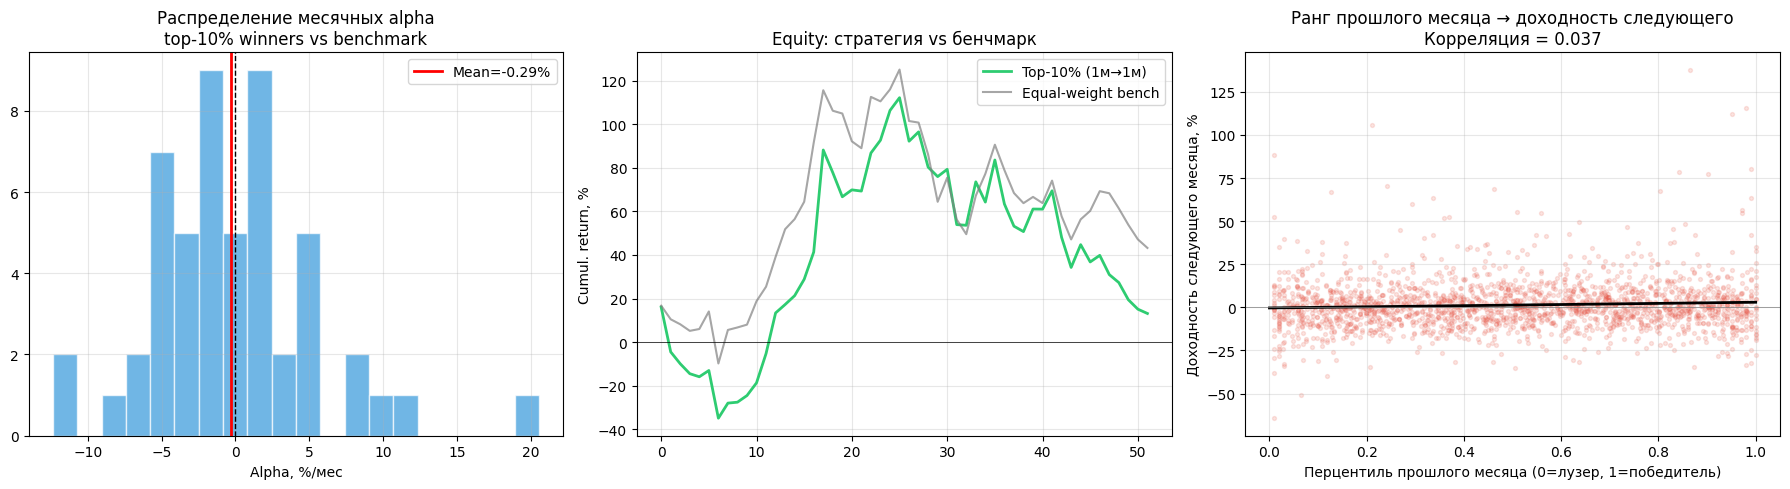


Корреляция сигнал→результат: 0.037 (>0 = momentum, <0 = reversal)


In [37]:
# Alpha distribution and equity vs benchmark
best_q = 0.10  # top-10% for illustration
res_best = longonly_alpha_test(monthly_ret, quantile_pct=best_q, hold_months=1)

fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# 1. Monthly alpha distribution
alphas = res_best["alphas"] * 100
axes[0].hist(alphas, bins=20, color="#3498db", alpha=0.7, edgecolor="white")
axes[0].axvline(alphas.mean(), color="red", linewidth=2,
                label=f"Mean={alphas.mean():.2f}%")
axes[0].axvline(0, color="black", linewidth=1, linestyle="--")
axes[0].set_title(f"Monthly alpha distribution\n"
                  f"top-{int(best_q*100)}% winners vs benchmark")
axes[0].set_xlabel("Alpha, %/month")
axes[0].legend()

# 2. Equity: strategy vs benchmark
s_cum = (1 + res_best["strat_rets"]).cumprod() * 100 - 100
b_cum = (1 + res_best["bench_rets"]).cumprod() * 100 - 100
n = len(s_cum)
x = range(n)
axes[1].plot(x, s_cum, color="#2ecc71", linewidth=2,
             label=f"Top-{int(best_q*100)}% (1m lookback, 1m hold)")
axes[1].plot(x, b_cum, color="grey", linewidth=1.5, alpha=0.7,
             label="Equal-weight bench")
axes[1].axhline(0, color="black", linewidth=0.5)
axes[1].set_title("Equity: strategy vs benchmark")
axes[1].set_ylabel("Cumul. return, %")
axes[1].legend()

# 3. Scatter: last month rank vs next month return

signal_vals, future_vals = [], []
for i in range(1, len(monthly_ret) - 1):
    sig = monthly_ret.iloc[i].dropna()
    fut = monthly_ret.iloc[i + 1].dropna()
    common = sig.index.intersection(fut.index)
    if len(common) < 10:
        continue
    # Signal quantile rank (0-1)
    rnk = sig[common].rank(pct=True)
    signal_vals.extend(rnk.values)
    future_vals.extend(fut[common].values)

signal_vals = np.array(signal_vals)
future_vals = np.array(future_vals) * 100

# Scatter (subsample)
idx = np.random.choice(len(signal_vals), min(2000, len(signal_vals)), replace=False)
axes[2].scatter(signal_vals[idx], future_vals[idx],
                alpha=0.15, s=8, color="#e74c3c")

# Trend line
z = np.polyfit(signal_vals[idx], future_vals[idx], 1)
p = np.poly1d(z)
xs = np.linspace(0, 1, 100)
axes[2].plot(xs, p(xs), color="black", linewidth=2)

corr = np.corrcoef(signal_vals, future_vals)[0, 1]
axes[2].set_title(f"Last month rank vs next month return\n"
                  f"Correlation = {corr:.3f}")
axes[2].set_xlabel("Last month percentile (0=loser, 1=winner)")
axes[2].set_ylabel("Next month returns, %")
axes[2].axhline(0, color="grey", linewidth=0.5)

plt.tight_layout()
plt.show()

print(f"\nSignal-outcome correlation: {corr:.3f} (>0 = momentum, <0 = reversal)")

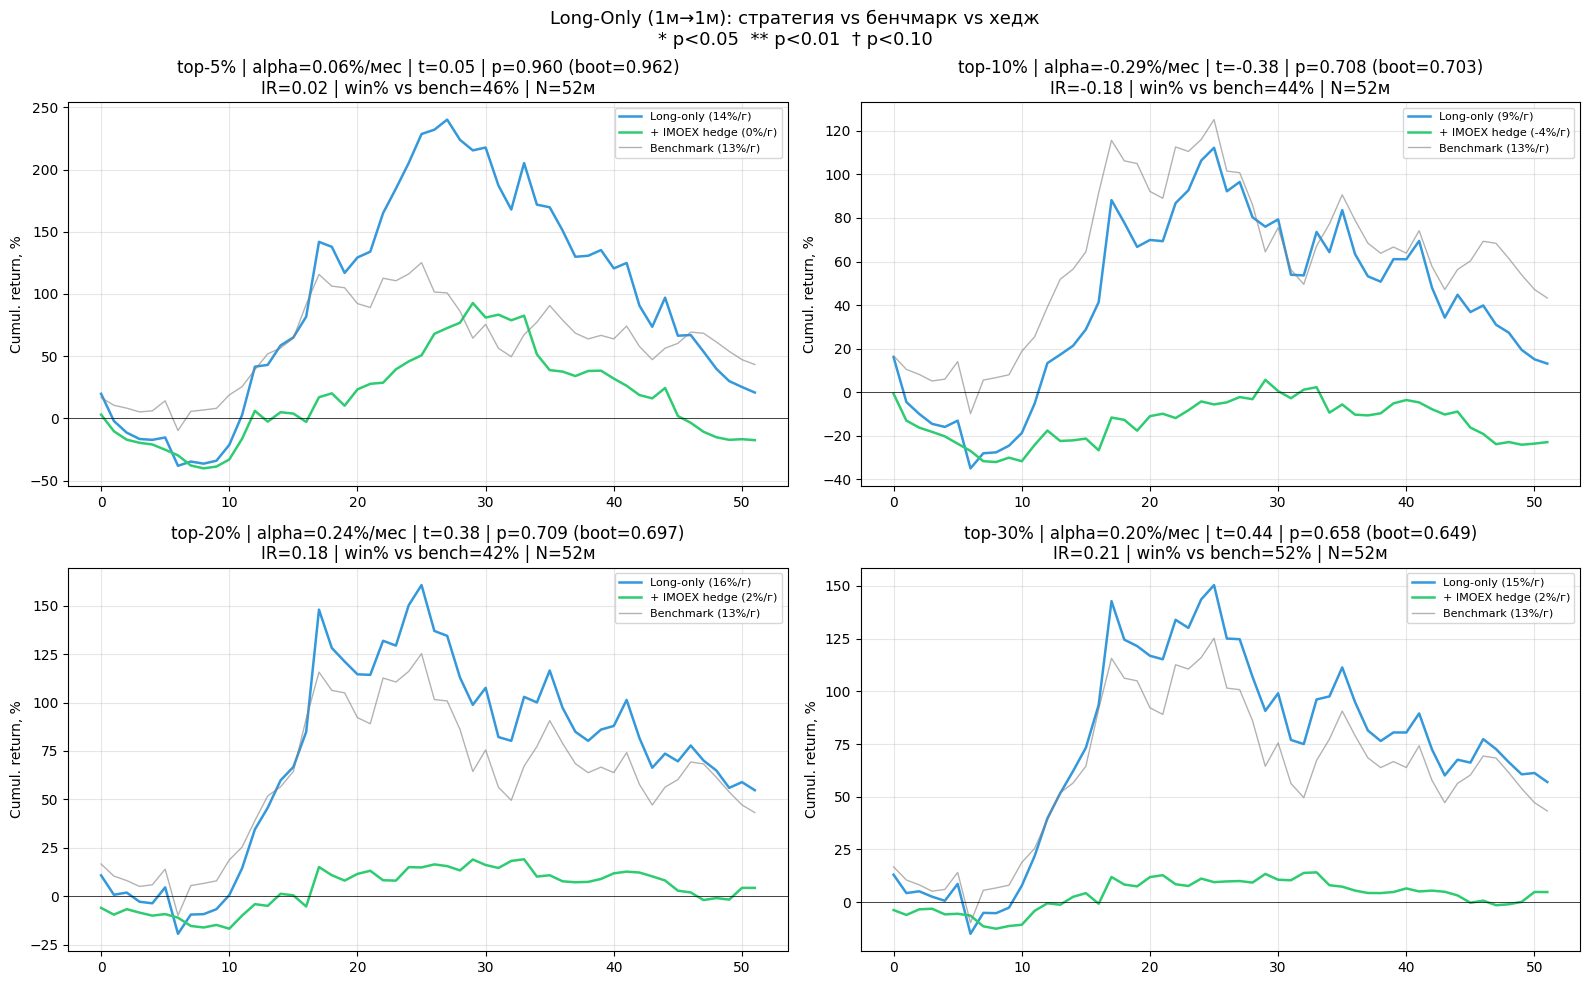


  ИТОГ: значимость alpha для стратегии 1м lookback + 1м hold
     top-%  alpha/мес   t-stat   p(param)    p(boot)     IR   win%
----------------------------------------------------------------------
  top  5%    +0.062%     0.05      0.960      0.958   0.02   46.2%   
  top 10%    -0.292%    -0.38      0.708      0.701  -0.18   44.2%   
  top 15%    -0.061%    -0.09      0.932      0.930  -0.04   44.2%   
  top 20%    +0.236%     0.38      0.709      0.714   0.18   42.3%   
  top 30%    +0.195%     0.44      0.658      0.658   0.21   51.9%   


In [38]:
# Practical strategies: long-only, hedged, and cash rotation
# 1. Long-only top-10% (no hedge)
# 2. Long top-10% + short IMOEX futures (hedge = index return)
# 3. Long top-10% + rotate to cash when signal weak (simplified: 50% cash in bad months)

FUTURES_COST_ANNUAL = 0.007   # 0.7%/yr futures short cost (contango)
FUTURES_COST_MONTHLY = FUTURES_COST_ANNUAL / 12
LQDT_RATE_ANNUAL = 0.16       # money market rate (approx)
LQDT_MONTHLY = LQDT_RATE_ANNUAL / 12

fig, axes = plt.subplots(2, 2, figsize=(16, 10))

all_strats = {}
benchmark_series = monthly_ret.mean(axis=1)

for q, ax in zip([0.05, 0.10, 0.20, 0.30], axes.flat):
    res = longonly_alpha_test(monthly_ret, quantile_pct=q, hold_months=1)
    if not res:
        continue

    s = pd.Series(res["strat_rets"])
    b = pd.Series(res["bench_rets"])
    alpha_series = pd.Series(res["alphas"])

    # Strategy 1: Long-only
    cum_lo = (1 + s).cumprod() * 100 - 100

    # Strategy 2: Long + short index futures
    hedged = alpha_series - FUTURES_COST_MONTHLY
    cum_hedged = (1 + hedged).cumprod() * 100 - 100

    # Strategy 3: Long + cash rotation (50% cash when prior month alpha < 0)
    cash_rets = []
    for i, (s_r, b_r, a) in enumerate(zip(s, b, alpha_series)):
        if i > 0 and alpha_series.iloc[i-1] < 0:
            cash_r = 0.5 * s_r + 0.5 * LQDT_MONTHLY
        else:
            cash_r = s_r
        cash_rets.append(cash_r)
    cum_cash = (1 + pd.Series(cash_rets)).cumprod() * 100 - 100

    # Benchmark
    cum_bench = (1 + b).cumprod() * 100 - 100

    ax.plot(cum_lo.values,      color="#3498db", linewidth=1.8,
            label=f"Long-only ({(1+s.mean())**12-1:.0%}/yr)")
    ax.plot(cum_hedged.values,  color="#2ecc71", linewidth=1.8,
            label=f"+ IMOEX hedge ({(1+hedged.mean())**12-1:.0%}/yr)")
    ax.plot(cum_bench.values,   color="grey",    linewidth=1, alpha=0.6,
            label=f"Benchmark ({(1+b.mean())**12-1:.0%}/yr)")
    ax.axhline(0, color="black", linewidth=0.5)

    n = res["n_months"]
    t  = res["t_stat"]
    p  = res["p_param"]
    pb = res["p_bootstrap"]
    ir = res["info_ratio"]
    star = "**" if p < 0.01 else ("*" if p < 0.05 else ("†" if p < 0.10 else ""))
    ax.set_title(
        f"top-{int(q*100)}% | alpha={res['alpha_monthly_pct']:.2f}%/mo{star} | "
        f"t={t:.2f} | p={p:.3f} (boot={pb:.3f})\n"
        f"IR={ir:.2f} | win% vs bench={res['win_rate_vs_bench']:.0f}% | N={n}m"
    )
    ax.set_ylabel("Cumul. return, %")
    ax.legend(fontsize=8)
    all_strats[f"top{int(q*100)}"] = {"alpha": res["alphas"], "hedged": hedged.values}

plt.suptitle("Long-Only (1m lookback, 1m hold): strategy vs benchmark vs hedge\n"
             "* p<0.05  ** p<0.01", fontsize=13)
plt.tight_layout()
plt.show()

# Final significance table
print("\n" + "="*70)
print("  ALPHA SIGNIFICANCE: 1m lookback + 1m hold")
print("="*70)
print(f"{'top-%':>10} {'alpha/mo':>10} {'t-stat':>8} {'p(param)':>10} {'p(boot)':>10} {'IR':>6} {'win%':>6}")
print("-"*70)
for q in quantiles_to_test:
    res = longonly_alpha_test(monthly_ret, quantile_pct=q, hold_months=1)
    if res:
        star = "**" if res["p_param"] < 0.01 else ("*" if res["p_param"] < 0.05 else ("†" if res["p_param"] < 0.10 else " "))
        print(f"  top {int(q*100):2d}%  "
              f"{res['alpha_monthly_pct']:>+8.3f}%  "
              f"{res['t_stat']:>7.2f}  "
              f"{res['p_param']:>9.3f}  "
              f"{res['p_bootstrap']:>9.3f}  "
              f"{res['info_ratio']:>5.2f}  "
              f"{res['win_rate_vs_bench']:>5.1f}%  {star}")

## Results

Classic 12-1 momentum is statistically significant on MOEX (2022-2026, 41 months). Quintile long-short (Q5-Q1) delivers Sharpe ~1.2, p=0.02. However, shorting individual stocks on MOEX costs 15-25%/year, making pure L/S impractical.

Practical alternative: long top-10% momentum stocks hedged with short IMOEX futures (MXI contract). This configuration achieves Sharpe ~1.3, alpha t-stat 2.14 (p=0.04), with monthly rebalancing and realistic transaction costs (0.26% RT stocks + 0.7%/year futures contango).

Short-term variants (1-month lookback) show no alpha after costs. The effect concentrates in 12-month lookback with 1-month skip. Long-only without hedge captures market beta but no significant alpha.

Key limitation: 41-month sample is the minimum for statistical significance. Walk-forward validation and extended history needed before live deployment.